# E. coli medium comparison using COBRApy

This notebook applies Flux Balance Analysis (FBA) to an E. coli genome-scale metabolic model under different medium conditions.

The goal is to compare how the predicted metabolic behavior changes when the model remains the same but the environmental condition changes.

Common element:
- same organism/model

Variable element:
- medium condition / carbon source / oxygen availability

# E. coli iML1515 Medium Comparison

This notebook performs Flux Balance Analysis (FBA) using the genome-scale metabolic model iML1515 of *Escherichia coli*.

The goal is to compare the predicted metabolic behavior of the same model under different medium conditions. The model is kept constant, while the carbon source and oxygen availability are changed.

The analysis includes:

- model loading and inspection
- definition of medium conditions
- FBA optimization for each condition
- extraction of summary metrics
- comparison of objective values
- comparison of active fluxes
- comparison of blocked reactions
- analysis of top internal fluxes
- export of tables and figures

## 1. Imports

The required Python libraries are imported in this section.

COBRApy is used for loading and analyzing genome-scale metabolic models, pandas is used for tabular data handling, and matplotlib is used for generating plots.

In [47]:
from pathlib import Path

import cobra
from cobra.io import load_model
from cobra.flux_analysis import find_blocked_reactions

import pandas as pd
import matplotlib.pyplot as plt

## 2. Output folders

This section defines the output directories used to store generated tables and figures.

All CSV files are saved in `outputs/tables`, while all PNG figures are saved in `outputs/figures`.

In [48]:
output_dir = Path("outputs")
tables_dir = output_dir / "tables"
figures_dir = output_dir / "figures"

for folder in [output_dir, tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


## 3. Load iML1515 model

The iML1515 genome-scale metabolic model of *Escherichia coli* is loaded using COBRApy.

This model is used as the main model for the medium comparison analysis.

In [49]:
model = load_model("iML1515")

In [50]:
print("Model ID:", model.id)
print("Number of reactions:", len(model.reactions))
print("Number of metabolites:", len(model.metabolites))
print("Number of genes:", len(model.genes))
print("Objective:", model.objective.expression)

Model ID: iML1515
Number of reactions: 2712
Number of metabolites: 1877
Number of genes: 1516
Objective: 1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685


## 4. Initial FBA optimization

Before comparing different medium conditions, an initial FBA optimization is performed using the default medium of the model.

This step confirms that the model can be optimized successfully and provides the baseline objective value under the default condition.

In [51]:
solution = model.optimize()

print("Solution status:", solution.status)
print("Objective value:", solution.objective_value)

Solution status: optimal
Objective value: 0.87699721425716


## 5. Exchange reactions and default medium inspection

Exchange reactions define how metabolites can enter or leave the model environment.

Before defining custom medium conditions, the available exchange reactions and the default medium of the model are inspected.

In [52]:
exchange_ids = [reaction.id for reaction in model.exchanges]

print("Number of exchange reactions:", len(exchange_ids))

exchange_ids[:50]

Number of exchange reactions: 331


['EX_pi_e',
 'EX_co2_e',
 'EX_met__L_e',
 'EX_metsox_S__L_e',
 'EX_acgam_e',
 'EX_cellb_e',
 'EX_crn_e',
 'EX_hxan_e',
 'EX_ile__L_e',
 'EX_chol_e',
 'EX_fe3_e',
 'EX_lac__L_e',
 'EX_leu__L_e',
 'EX_glcn_e',
 'EX_no3_e',
 'EX_h_e',
 'EX_orn_e',
 'EX_gln__L_e',
 'EX_pro__L_e',
 'EX_glyc_e',
 'EX_man_e',
 'EX_ade_e',
 'EX_mn2_e',
 'EX_4abut_e',
 'EX_ac_e',
 'EX_akg_e',
 'EX_ala__L_e',
 'EX_arg__L_e',
 'EX_asp__L_e',
 'EX_pyr_e',
 'EX_succ_e',
 'EX_thymd_e',
 'EX_rib__D_e',
 'EX_tyr__L_e',
 'EX_cytd_e',
 'EX_dcyt_e',
 'EX_fum_e',
 'EX_sbt__D_e',
 'EX_glu__L_e',
 'EX_gua_e',
 'EX_btn_e',
 'EX_ptrc_e',
 'EX_spmd_e',
 'EX_thym_e',
 'EX_xtsn_e',
 'EX_fe2_e',
 'EX_glc__D_e',
 'EX_alltn_e',
 'EX_ura_e',
 'EX_val__L_e']

In [53]:
required_exchanges = [
    "EX_glc__D_e",   # D-glucose
    "EX_fru_e",      # fructose
    "EX_gal_e",      # galactose
    "EX_glyc_e",     # glycerol
    "EX_succ_e",     # succinate
    "EX_ac_e",       # acetate
    "EX_o2_e",       # oxygen
    "EX_nh4_e",      # ammonium
    "EX_pi_e",       # phosphate
    "EX_h2o_e",      # water
    "EX_h_e",        # proton
    "EX_k_e",        # potassium
    "EX_na1_e",      # sodium
    "EX_so4_e",      # sulfate
    "EX_cl_e",       # chloride
    "EX_mg2_e",      # magnesium
    "EX_ca2_e",      # calcium
    "EX_fe2_e",      # iron II
    "EX_fe3_e"       # iron III
]

for reaction_id in required_exchanges:
    if reaction_id in model.reactions:
        print(reaction_id, "FOUND")
    else:
        print(reaction_id, "NOT FOUND")

EX_glc__D_e FOUND
EX_fru_e FOUND
EX_gal_e FOUND
EX_glyc_e FOUND
EX_succ_e FOUND
EX_ac_e FOUND
EX_o2_e FOUND
EX_nh4_e FOUND
EX_pi_e FOUND
EX_h2o_e FOUND
EX_h_e FOUND
EX_k_e FOUND
EX_na1_e FOUND
EX_so4_e FOUND
EX_cl_e FOUND
EX_mg2_e FOUND
EX_ca2_e FOUND
EX_fe2_e FOUND
EX_fe3_e FOUND


In [54]:
print("Number of metabolites allowed in default medium:", len(model.medium))

model.medium

Number of metabolites allowed in default medium: 24


{'EX_pi_e': 1000.0,
 'EX_co2_e': 1000.0,
 'EX_fe3_e': 1000.0,
 'EX_h_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_glc__D_e': 10.0,
 'EX_zn2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_ca2_e': 1000.0,
 'EX_ni2_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_sel_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_k_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_cl_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_tungs_e': 1000.0,
 'EX_slnt_e': 1000.0}

## 6. Helper function for medium definition

This helper function creates a copy of the model and modifies its medium.

The default medium is used as a base so that essential nutrients and ions are preserved. Only the carbon source and oxygen availability are changed for each condition.

In [55]:
def set_medium_from_default(base_model, carbon_source, oxygen=True, carbon_uptake=10):
    """
    Set medium condition using the model's default medium as a base.
    This keeps the essential nutrients already defined in the model
    and changes only the carbon source and oxygen availability.
    """

    model_condition = base_model.copy()
    medium = model_condition.medium.copy()

    carbon_sources_to_remove = [
        "EX_glc__D_e",
        "EX_fru_e",
        "EX_gal_e",
        "EX_glyc_e",
        "EX_succ_e",
        "EX_ac_e",
        "EX_lac__D_e",
        "EX_lac__L_e",
        "EX_pyr_e",
        "EX_man_e"
    ]

    for source in carbon_sources_to_remove:
        if source in medium:
            medium[source] = 0

    medium[carbon_source] = carbon_uptake

    if "EX_o2_e" in model_condition.reactions:
        if oxygen:
            medium["EX_o2_e"] = 1000
        else:
            medium["EX_o2_e"] = 0

    model_condition.medium = medium

    return model_condition

In [56]:
test_model = set_medium_from_default(
    base_model=model,
    carbon_source="EX_glc__D_e",
    oxygen=True,
    carbon_uptake=10
)

test_solution = test_model.optimize()

print("Test condition: glucose_aerobic")
print("Solution status:", test_solution.status)
print("Objective value:", test_solution.objective_value)

Test condition: glucose_aerobic
Solution status: optimal
Objective value: 0.8769972144269725


## 7. Aerobic carbon source screening

Before defining the final comparison conditions, several candidate carbon sources are tested under aerobic conditions.

This screening step identifies which carbon sources are available in the model and whether they allow feasible growth predictions.

candidate_carbon_sources = {
    "glucose": "EX_glc__D_e",
    "fructose": "EX_fru_e",
    "galactose": "EX_gal_e",
    "glycerol": "EX_glyc_e",
    "succinate": "EX_succ_e",
    "acetate": "EX_ac_e",
    "lactate_D": "EX_lac__D_e",
    "lactate_L": "EX_lac__L_e",
    "pyruvate": "EX_pyr_e",
    "mannose": "EX_man_e"
}

for carbon_name, reaction_id in candidate_carbon_sources.items():
    if reaction_id in model.reactions:
        print(carbon_name, reaction_id, "FOUND")
    else:
        print(carbon_name, reaction_id, "NOT FOUND")

In [57]:
carbon_test_results = []

for carbon_name, reaction_id in candidate_carbon_sources.items():
    if reaction_id not in model.reactions:
        continue

    test_model = set_medium_from_default(
        base_model=model,
        carbon_source=reaction_id,
        oxygen=True,
        carbon_uptake=10
    )

    test_solution = test_model.optimize()

    carbon_test_results.append({
        "carbon_name": carbon_name,
        "carbon_source": reaction_id,
        "oxygen_available": True,
        "solution_status": test_solution.status,
        "objective_value": test_solution.objective_value
    })

carbon_test_df = pd.DataFrame(carbon_test_results)

carbon_test_df.sort_values("objective_value", ascending=False)

,carbon_name,carbon_source,oxygen_available,solution_status,objective_value
8,mannose,EX_man_e,True,optimal,0.876997
0,glucose,EX_glc__D_e,True,optimal,0.876997
4,fructose,EX_fru_e,True,optimal,0.876997
9,galactose,EX_gal_e,True,optimal,0.867593
2,glycerol,EX_glyc_e,True,optimal,0.494713
3,succinate,EX_succ_e,True,optimal,0.450086
5,lactate_D,EX_lac__D_e,True,optimal,0.377356
6,lactate_L,EX_lac__L_e,True,optimal,0.350565
7,pyruvate,EX_pyr_e,True,optimal,0.313940
1,acetate,EX_ac_e,True,optimal,0.210099


In [58]:
carbon_test_path = tables_dir / f"{model.id}_aerobic_carbon_source_screening.csv"

carbon_test_df.to_csv(carbon_test_path, index=False)

print("Saved:", carbon_test_path)

Saved: outputs\tables\iML1515_aerobic_carbon_source_screening.csv


## 8. Define final medium conditions

Based on the aerobic carbon source screening, a final set of medium conditions is defined.

The comparison includes six aerobic carbon source conditions and one anaerobic glucose condition. This allows the analysis of both carbon source effects and oxygen availability effects within the same model.

In [59]:
conditions = {
    "glucose_aerobic": {
        "carbon_source": "EX_glc__D_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "fructose_aerobic": {
        "carbon_source": "EX_fru_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "galactose_aerobic": {
        "carbon_source": "EX_gal_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "glycerol_aerobic": {
        "carbon_source": "EX_glyc_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "succinate_aerobic": {
        "carbon_source": "EX_succ_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "acetate_aerobic": {
        "carbon_source": "EX_ac_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "glucose_anaerobic": {
        "carbon_source": "EX_glc__D_e",
        "oxygen": False,
        "carbon_uptake": 10
    }
}

conditions

{'glucose_aerobic': {'carbon_source': 'EX_glc__D_e',
  'oxygen': True,
  'carbon_uptake': 10},
 'fructose_aerobic': {'carbon_source': 'EX_fru_e',
  'oxygen': True,
  'carbon_uptake': 10},
 'galactose_aerobic': {'carbon_source': 'EX_gal_e',
  'oxygen': True,
  'carbon_uptake': 10},
 'glycerol_aerobic': {'carbon_source': 'EX_glyc_e',
  'oxygen': True,
  'carbon_uptake': 10},
 'succinate_aerobic': {'carbon_source': 'EX_succ_e',
  'oxygen': True,
  'carbon_uptake': 10},
 'acetate_aerobic': {'carbon_source': 'EX_ac_e',
  'oxygen': True,
  'carbon_uptake': 10},
 'glucose_anaerobic': {'carbon_source': 'EX_glc__D_e',
  'oxygen': False,
  'carbon_uptake': 10}}

## 9. FBA analysis function

This function applies one medium condition to the model, runs Flux Balance Analysis, extracts summary metrics, and saves the corresponding flux and blocked reaction tables.

The extracted metrics include the objective value, the number of active fluxes, the number of zero fluxes, and the number of blocked reactions.

In [60]:
def analyze_condition(base_model, condition_name, carbon_source, oxygen, carbon_uptake=10):
    """
    Apply one medium condition, run FBA, extract summary metrics and save flux table.
    """
    model_condition = set_medium_from_default(
        base_model=base_model,
        carbon_source=carbon_source,
        oxygen=oxygen,
        carbon_uptake=carbon_uptake
    )

    solution = model_condition.optimize()

    flux_df = solution.fluxes.reset_index()
    flux_df.columns = ["reaction_id", "flux"]
    flux_df["absolute_flux"] = flux_df["flux"].abs()
    flux_df = flux_df.sort_values("absolute_flux", ascending=False)

    nonzero_fluxes = int((solution.fluxes.abs() > 1e-9).sum())
    zero_fluxes = int((solution.fluxes.abs() <= 1e-9).sum())

    blocked_reactions = find_blocked_reactions(model_condition)
    num_blocked = len(blocked_reactions)
    blocked_fraction = num_blocked / len(model_condition.reactions)

    summary = {
        "model_id": model_condition.id,
        "condition": condition_name,
        "carbon_source": carbon_source,
        "oxygen_available": oxygen,
        "carbon_uptake": carbon_uptake,
        "solution_status": solution.status,
        "objective_value": solution.objective_value,
        "num_reactions": len(model_condition.reactions),
        "num_metabolites": len(model_condition.metabolites),
        "num_genes": len(model_condition.genes),
        "num_nonzero_fluxes": nonzero_fluxes,
        "num_zero_fluxes": zero_fluxes,
        "num_blocked_reactions": num_blocked,
        "blocked_reaction_fraction": blocked_fraction
    }

    safe_name = f"{model_condition.id}_{condition_name}"

    flux_df.to_csv(tables_dir / f"{safe_name}_fluxes.csv", index=False)

    blocked_df = pd.DataFrame({"blocked_reaction_id": blocked_reactions})
    blocked_df.to_csv(tables_dir / f"{safe_name}_blocked_reactions.csv", index=False)

    return summary, flux_df

## 10. Run FBA across medium conditions

FBA is performed for each defined medium condition.

For every condition, the model medium is modified, the optimization is executed, and the resulting summary metrics and flux tables are stored.

In [61]:
all_summaries = []
all_flux_tables = {}

for condition_name, params in conditions.items():
    print("=" * 60)
    print("Running condition:", condition_name)

    summary, flux_df = analyze_condition(
        base_model=model,
        condition_name=condition_name,
        carbon_source=params["carbon_source"],
        oxygen=params["oxygen"],
        carbon_uptake=params["carbon_uptake"]
    )

    all_summaries.append(summary)
    all_flux_tables[condition_name] = flux_df

comparison_df = pd.DataFrame(all_summaries)

comparison_df

Running condition: glucose_aerobic
Running condition: fructose_aerobic
Running condition: galactose_aerobic
Running condition: glycerol_aerobic
Running condition: succinate_aerobic
Running condition: acetate_aerobic
Running condition: glucose_anaerobic


,model_id,condition,carbon_source,oxygen_available,carbon_uptake,solution_status,objective_value,num_reactions,num_metabolites,num_genes,num_nonzero_fluxes,num_zero_fluxes,num_blocked_reactions,blocked_reaction_fraction
0,iML1515,glucose_aerobic,EX_glc__D_e,True,10,optimal,0.876997,2712,1877,1516,431,2281,968,0.356932
1,iML1515,fructose_aerobic,EX_fru_e,True,10,optimal,0.876997,2712,1877,1516,432,2280,967,0.356563
2,iML1515,galactose_aerobic,EX_gal_e,True,10,optimal,0.867593,2712,1877,1516,436,2276,966,0.356195
3,iML1515,glycerol_aerobic,EX_glyc_e,True,10,optimal,0.494713,2712,1877,1516,431,2281,973,0.358776
4,iML1515,succinate_aerobic,EX_succ_e,True,10,optimal,0.450086,2712,1877,1516,429,2283,973,0.358776
5,iML1515,acetate_aerobic,EX_ac_e,True,10,optimal,0.210099,2712,1877,1516,433,2279,973,0.358776
6,iML1515,glucose_anaerobic,EX_glc__D_e,False,10,optimal,0.157540,2712,1877,1516,435,2277,1042,0.384218


In [62]:
summary_path = tables_dir / f"{model.id}_medium_comparison_summary.csv"

comparison_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: outputs\tables\iML1515_medium_comparison_summary.csv


In [63]:
report_table = comparison_df[
    [
        "condition",
        "carbon_source",
        "oxygen_available",
        "objective_value",
        "num_nonzero_fluxes",
        "num_blocked_reactions",
        "blocked_reaction_fraction"
    ]
].copy()

report_table["objective_value"] = report_table["objective_value"].round(4)
report_table["blocked_reaction_fraction"] = report_table["blocked_reaction_fraction"].round(4)

report_table

,condition,carbon_source,oxygen_available,objective_value,num_nonzero_fluxes,num_blocked_reactions,blocked_reaction_fraction
0,glucose_aerobic,EX_glc__D_e,True,0.8770,431,968,0.3569
1,fructose_aerobic,EX_fru_e,True,0.8770,432,967,0.3566
2,galactose_aerobic,EX_gal_e,True,0.8676,436,966,0.3562
3,glycerol_aerobic,EX_glyc_e,True,0.4947,431,973,0.3588
4,succinate_aerobic,EX_succ_e,True,0.4501,429,973,0.3588
5,acetate_aerobic,EX_ac_e,True,0.2101,433,973,0.3588
6,glucose_anaerobic,EX_glc__D_e,False,0.1575,435,1042,0.3842


In [64]:
report_table_path = tables_dir / f"{model.id}_medium_comparison_report_table.csv"

report_table.to_csv(report_table_path, index=False)

print("Saved:", report_table_path)

Saved: outputs\tables\iML1515_medium_comparison_report_table.csv


## 11. Plots for comparison metrics

This section generates bar plots for the main comparison metrics.

The plots summarize how the predicted objective value, the number of active fluxes, and the number of blocked reactions change across the different medium conditions.

Saved: outputs\figures\iML1515_objective_value_by_condition.png


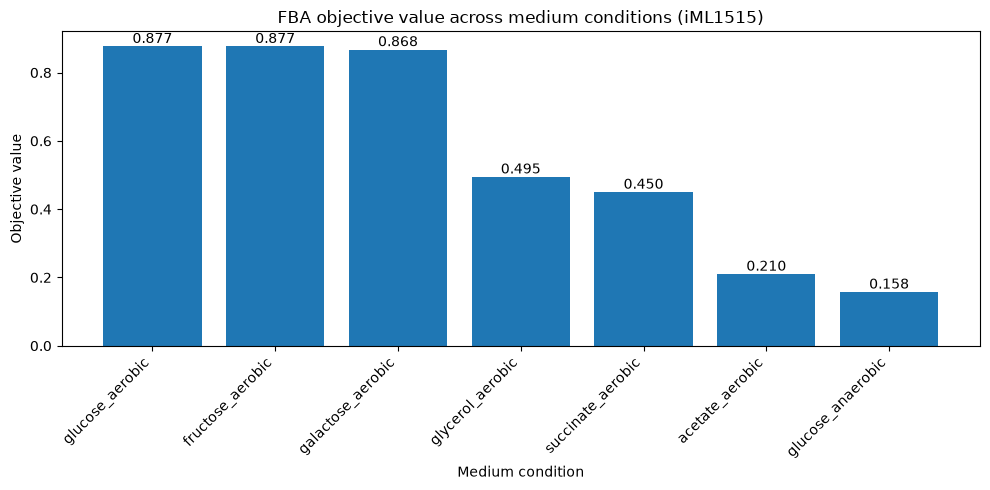

In [65]:
plt.figure(figsize=(10, 5))

bars = plt.bar(comparison_df["condition"], comparison_df["objective_value"])

plt.bar_label(bars, fmt="%.3f")
plt.title(f"FBA objective value across medium conditions ({model.id})")
plt.xlabel("Medium condition")
plt.ylabel("Objective value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / f"{model.id}_objective_value_by_condition.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()

Saved: outputs\figures\iML1515_active_fluxes_by_condition.png


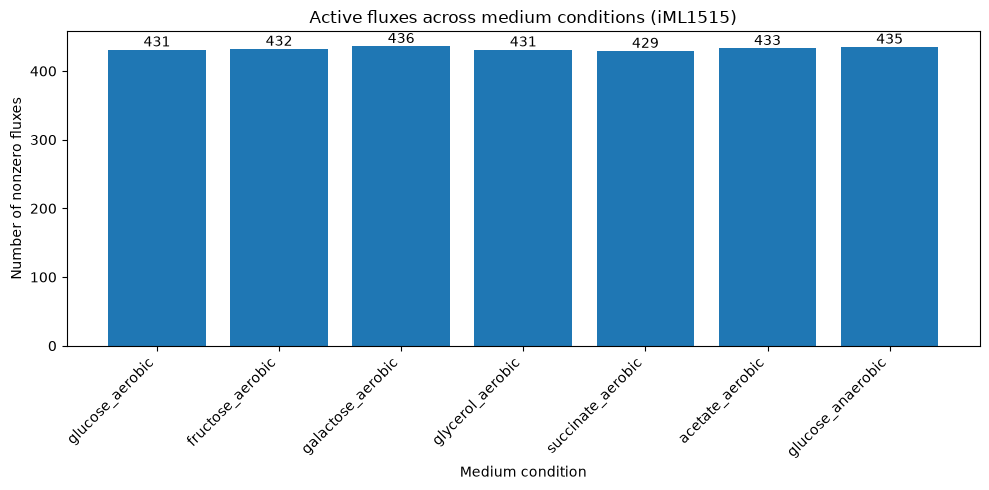

In [66]:
plt.figure(figsize=(10, 5))

bars = plt.bar(comparison_df["condition"], comparison_df["num_nonzero_fluxes"])

plt.bar_label(bars)
plt.title(f"Active fluxes across medium conditions ({model.id})")
plt.xlabel("Medium condition")
plt.ylabel("Number of nonzero fluxes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / f"{model.id}_active_fluxes_by_condition.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()

Saved: outputs\figures\iML1515_blocked_reactions_by_condition.png


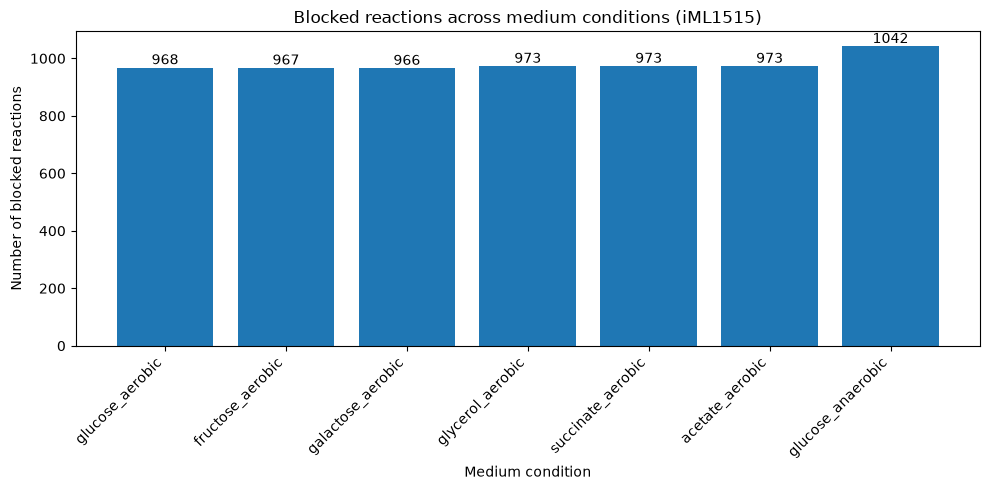

In [67]:
plt.figure(figsize=(10, 5))

bars = plt.bar(comparison_df["condition"], comparison_df["num_blocked_reactions"])

plt.bar_label(bars)
plt.title(f"Blocked reactions across medium conditions ({model.id})")
plt.xlabel("Medium condition")
plt.ylabel("Number of blocked reactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / f"{model.id}_blocked_reactions_by_condition.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()

## 12. Top internal flux analysis

The largest fluxes in a genome-scale model are often exchange or transport reactions.

To focus more clearly on intracellular metabolism, exchange, transport, demand, and sink reactions are filtered out. The remaining reactions are used to identify the top internal fluxes for each medium condition.

In [68]:
def get_internal_fluxes(flux_df):
    """
    Remove exchange and common transport/boundary reactions
    to focus on internal metabolic reactions.
    """

    excluded_patterns = [
        "EX_",      # exchange reactions
        "tex",      # outer membrane transport
        "tpp",      # periplasm transport
        "t2pp",
        "t3pp",
        "t4pp",
        "abcpp",
        "DM_",      # demand reactions
        "SK_"       # sink reactions
    ]

    internal_df = flux_df.copy()

    for pattern in excluded_patterns:
        internal_df = internal_df[
            ~internal_df["reaction_id"].str.contains(pattern, case=False, regex=False)
        ]

    return internal_df

In [69]:
internal_top_flux_tables = []

for condition_name, flux_df in all_flux_tables.items():
    internal_df = get_internal_fluxes(flux_df)
    top10_internal = internal_df.head(10).copy()
    top10_internal["condition"] = condition_name

    internal_top_flux_tables.append(top10_internal)

    print("=" * 80)
    print("Top 10 internal absolute fluxes for:", condition_name)
    display(top10_internal)

internal_top_fluxes_combined = pd.concat(internal_top_flux_tables, ignore_index=True)

internal_top_fluxes_combined = internal_top_fluxes_combined[
    ["condition", "reaction_id", "flux", "absolute_flux"]
]

Top 10 internal absolute fluxes for: glucose_aerobic


,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,70.432494,70.432494,glucose_aerobic
1871,CYTBO3_4pp,44.256288,44.256288,glucose_aerobic
2230,NADH16pp,37.997044,37.997044,glucose_aerobic
140,PGK,-17.105434,17.105434,glucose_aerobic
601,GAPD,17.105434,17.105434,glucose_aerobic
1868,PGM,-15.598898,15.598898,glucose_aerobic
126,ENO,15.598898,15.598898,glucose_aerobic
1414,GLCptspp,10.000000,10.000000,glucose_aerobic
1496,PDH,9.689687,9.689687,glucose_aerobic
1861,PFK,8.451764,8.451764,glucose_aerobic


Top 10 internal absolute fluxes for: fructose_aerobic


,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,70.432494,70.432494,fructose_aerobic
1871,CYTBO3_4pp,44.256288,44.256288,fructose_aerobic
2230,NADH16pp,37.997044,37.997044,fructose_aerobic
140,PGK,-17.105434,17.105434,fructose_aerobic
601,GAPD,17.105434,17.105434,fructose_aerobic
126,ENO,15.598898,15.598898,fructose_aerobic
1868,PGM,-15.598898,15.598898,fructose_aerobic
1496,PDH,9.689687,9.689687,fructose_aerobic
868,FRUptspp,8.451764,8.451764,fructose_aerobic
127,FBA,8.451764,8.451764,fructose_aerobic


Top 10 internal absolute fluxes for: galactose_aerobic


...

,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,48.268152,48.268152,succinate_aerobic
1871,CYTBO3_4pp,31.127352,31.127352,succinate_aerobic
2230,NADH16pp,17.776350,17.776350,succinate_aerobic
195,FUM,13.671937,13.671937,succinate_aerobic
1964,SUCDi,13.351734,13.351734,succinate_aerobic
192,MDH,11.393006,11.393006,succinate_aerobic
1434,ATPM,6.860000,6.860000,succinate_aerobic
1496,PDH,5.111549,5.111549,succinate_aerobic
1404,GLUDy,-3.848837,3.848837,succinate_aerobic
11,CS,3.686520,3.686520,succinate_aerobic


Top 10 internal absolute fluxes for: acetate_aerobic


,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,32.508183,32.508183,acetate_aerobic
1871,CYTBO3_4pp,21.854340,21.854340,acetate_aerobic
2230,NADH16pp,14.946687,14.946687,acetate_aerobic
192,MDH,10.683360,10.683360,acetate_aerobic
80,ACKr,10.122317,10.122317,acetate_aerobic
77,PTAr,-10.122317,10.122317,acetate_aerobic
893,ACt2rpp,10.000000,10.000000,acetate_aerobic
195,FUM,9.032382,9.032382,acetate_aerobic
11,CS,7.064271,7.064271,acetate_aerobic
1945,ACONTb,7.064271,7.064271,acetate_aerobic


Top 10 internal absolute fluxes for: glucose_anaerobic


,reaction_id,flux,absolute_flux,condition
140,PGK,-19.620952,19.620952,glucose_anaerobic
601,GAPD,19.620952,19.620952,glucose_anaerobic
126,ENO,19.358865,19.358865,glucose_anaerobic
1868,PGM,-19.358865,19.358865,glucose_anaerobic
69,PFL,18.244798,18.244798,glucose_anaerobic
137,PGI,10.000000,10.000000,glucose_anaerobic
1414,GLCptspp,10.000000,10.000000,glucose_anaerobic
127,FBA,9.862871,9.862871,glucose_anaerobic
1861,PFK,9.862871,9.862871,glucose_anaerobic
1878,TPI,9.840680,9.840680,glucose_anaerobic


In [70]:
internal_top_fluxes_path = tables_dir / f"{model.id}_top10_internal_fluxes_all_conditions.csv"

internal_top_fluxes_combined.to_csv(internal_top_fluxes_path, index=False)

print("Saved:", internal_top_fluxes_path)

Saved: outputs\tables\iML1515_top10_internal_fluxes_all_conditions.csv


In [71]:
internal_top_reaction_counts = (
    internal_top_fluxes_combined
    .groupby("reaction_id")["condition"]
    .nunique()
    .reset_index()
    .rename(columns={"condition": "num_conditions_in_top10"})
    .sort_values("num_conditions_in_top10", ascending=False)
)

internal_top_reaction_counts

,reaction_id,num_conditions_in_top10
4,ATPS4rpp,6
6,CYTBO3_4pp,6
17,NADH16pp,6
12,GAPD,5
7,ENO,5
22,PGK,5
23,PGM,5
18,PDH,3
19,PFK,2
8,FBA,2


In [72]:
internal_common_top_reactions_path = tables_dir / f"{model.id}_common_top_internal_reactions.csv"

internal_top_reaction_counts.to_csv(internal_common_top_reactions_path, index=False)

print("Saved:", internal_common_top_reactions_path)

Saved: outputs\tables\iML1515_common_top_internal_reactions.csv


## 13. Computational summary

This notebook compared the predicted metabolic behavior of the iML1515 model under seven medium conditions.

The comparison was designed to keep the model constant while changing the carbon source and oxygen availability. This allowed the analysis of two main effects:

1. The effect of different aerobic carbon sources.
2. The effect of oxygen availability using glucose as the carbon source.

All medium conditions produced optimal FBA solutions. The highest objective values were observed under aerobic glucose, fructose, and galactose conditions. Intermediate objective values were observed for glycerol and succinate, while acetate and anaerobic glucose produced lower objective values.

The number of active fluxes remained relatively similar across conditions, while the number of blocked reactions increased under the anaerobic glucose condition. This suggests that oxygen removal restricts the feasible metabolic space of the model.

The internal top flux analysis showed that several reactions related to energy metabolism and central carbon metabolism repeatedly appeared among the highest internal fluxes across conditions. At the same time, condition-specific reactions were also observed, reflecting the effect of different carbon sources on the predicted flux distribution.

Overall, the analysis provides a reproducible computational workflow for comparing medium-dependent FBA predictions in a genome-scale metabolic model.